# 📊 Plotting — o módulo `st.pl`

Este tutorial percorre as funções de visualização do **spatools**:

| função | para quê |
|---|---|
| `st.pl.spatial_plot` | mapear clusters, expressão gênica ou só o tecido, um painel por amostra |
| `st.pl.bar` | composição de clusters por grupo (barras empilhadas) |
| `st.pl.clusters_quality_violin_boxplot` | métricas de qualidade cluster a cluster |
| `st.con.*` | paletas de cor prontas |

As funções de QC de pré-processamento (`st.pl.outlier_quality`,
`st.pl.preprocessing_quality_metrics`) ficam em
[Pre-processing.ipynb](./Pre-processing.ipynb), e o heatmap de colocalização
(`st.pl.z_score_matrixplot`) em
[clustering_correlation_analysis.ipynb](./clustering_correlation_analysis.ipynb).

## Dados

Dataset público de cérebro de camundongo (Visium H&E) do **squidpy**, que já traz clusters
anotados por região (`obs["cluster"]`) e clusters de Leiden (`obs["leiden"]`).

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

import spatools as st

DATA = os.path.join("data", "anndata", "visium_hne_adata.h5ad")

if not os.path.exists(DATA):
    import squidpy as sq
    os.makedirs(os.path.dirname(DATA), exist_ok=True)
    sq.datasets.visium_hne_adata(path=DATA)

adata = sc.read_h5ad(DATA)
adata

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

## 1. `spatial_plot`

Desenha **um painel por valor de `sample_key`**. Para cada painel ele busca a imagem do
tecido em `adata.uns["spatial"][valor]` — então os valores dessa coluna precisam ser
exatamente as chaves de `uns["spatial"]`.

Este objeto tem uma amostra só, então criamos uma coluna com essa única chave.

In [2]:
CHAVE = list(adata.uns["spatial"])[0]
print("chave em uns['spatial']:", CHAVE)

adata.obs["sample"] = CHAVE
adata.obs["sample"] = adata.obs["sample"].astype("category")

chave em uns['spatial']: V1_Adult_Mouse_Brain


### 1.1 Só o tecido

Com `scatter_plot=False` nenhum spot é desenhado e os eixos passam a ficar em **milímetros**,
usando os fatores de escala do Visium. Útil para conferir a lâmina antes de qualquer
análise.

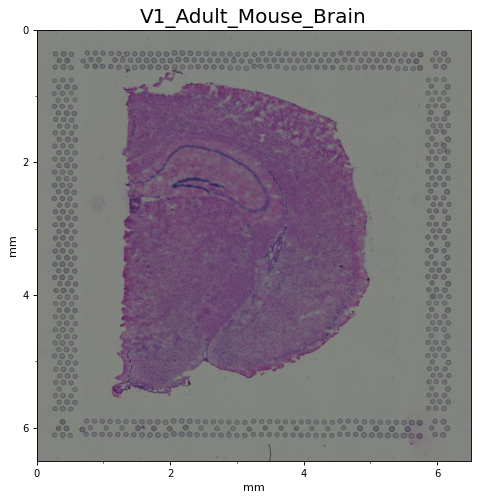

In [3]:
st.pl.spatial_plot(
    adata,
    scatter_plot=False,
    sample_key="sample",
    figsize=(7, 7),
    dpi=80,
)

### 1.2 Colorindo por uma coluna categórica

Passe o nome da coluna em `group`. As cores saem de `adata.uns[f"{group}_colors"]` quando
existe; senão o `spatial_plot` cai para `tab20` (ou `turbo`, se houver mais categorias que
cores disponíveis).

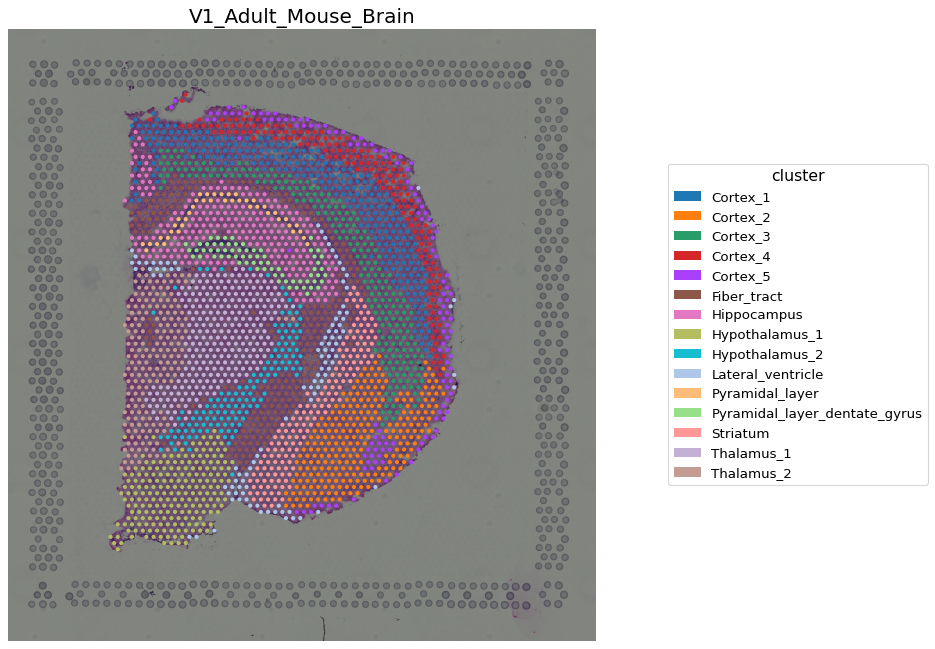

In [4]:
st.pl.spatial_plot(
    adata,
    group="cluster",
    sample_key="sample",
    spot_size=14,
    figsize=(9, 8),
    dpi=80,
)

### 1.3 Destacando categorias com `highlight`

Tudo que não estiver em `highlight` fica cinza. Aceita um valor único ou uma lista
(até três categorias ganham cor própria: vermelho, amarelo e azul).

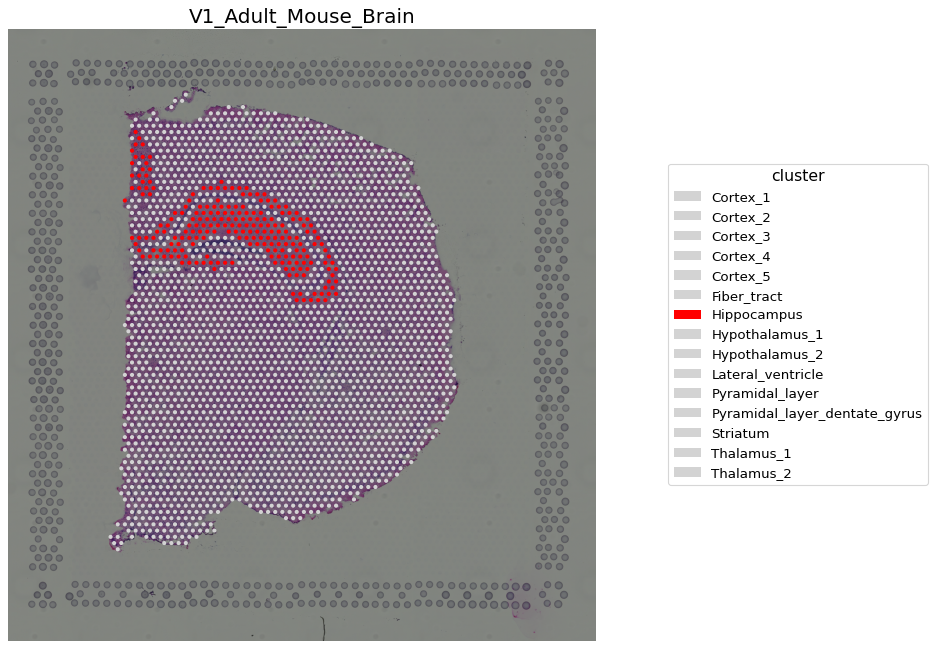

In [5]:
st.pl.spatial_plot(
    adata,
    group="cluster",
    highlight="Hippocampus",
    sample_key="sample",
    spot_size=14,
    figsize=(9, 8),
    dpi=80,
)

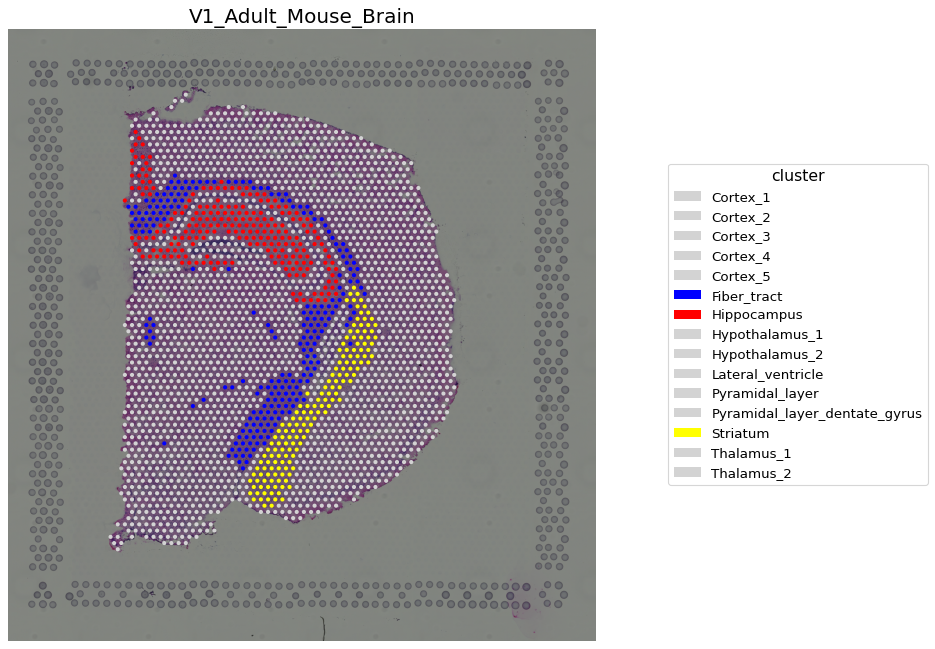

In [6]:
st.pl.spatial_plot(
    adata,
    group="cluster",
    highlight=["Hippocampus", "Striatum", "Fiber_tract"],
    sample_key="sample",
    spot_size=14,
    figsize=(9, 8),
    dpi=80,
)

### 1.4 Colorindo por expressão gênica

Se o valor de `group` for um nome em `adata.var_names` em vez de uma coluna de `obs`, o
`spatial_plot` troca para escala contínua (`plasma`) e desenha uma colorbar. A escala é
calculada sobre **todas** as amostras, para que painéis diferentes fiquem comparáveis.

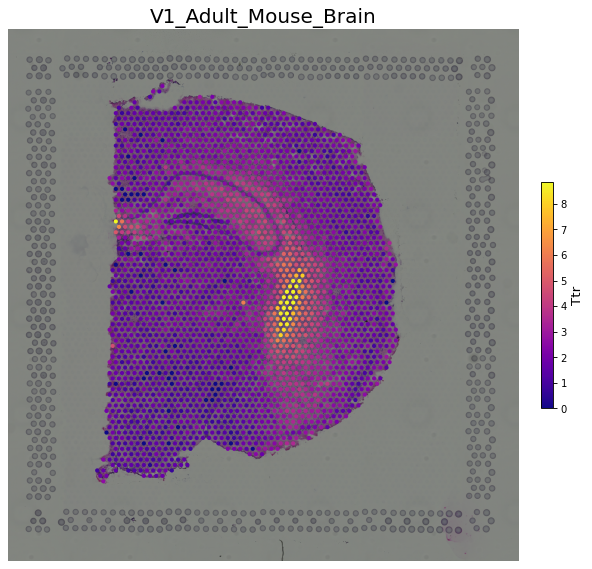

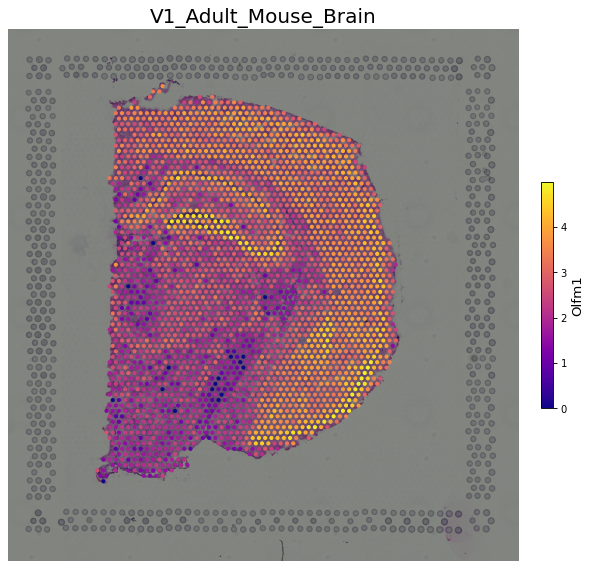

In [7]:
# Ttr: marcador de plexo coróide. Olho: marcador de neurônios do hipocampo.
for gene in ["Ttr", "Olfm1"]:
    st.pl.spatial_plot(
        adata,
        group=gene,
        sample_key="sample",
        spot_size=14,
        figsize=(8, 7),
        dpi=80,
    )

### 1.5 Cores customizadas

`custom_colors` aceita um **dict** `{categoria: cor}` (sobrescreve só o que você listar) ou
uma **lista** do mesmo tamanho do número de categorias (substitui a paleta inteira).

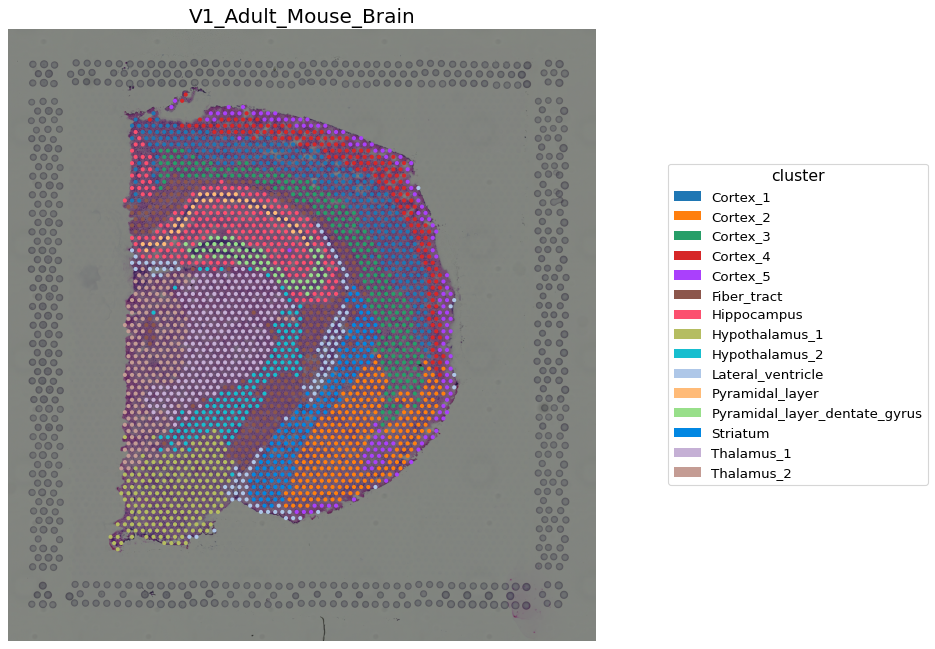

In [8]:
st.pl.spatial_plot(
    adata,
    group="cluster",
    custom_colors={"Hippocampus": "#FC506F", "Striatum": "#0187E2"},
    sample_key="sample",
    spot_size=14,
    figsize=(9, 8),
    dpi=80,
)

### 1.6 Várias amostras

O caso real: um objeto com amostras concatenadas. Aqui simulamos partindo a lâmina ao meio
e registrando as duas metades como se fossem amostras distintas — repare que cada chave
precisa existir em `uns["spatial"]`.

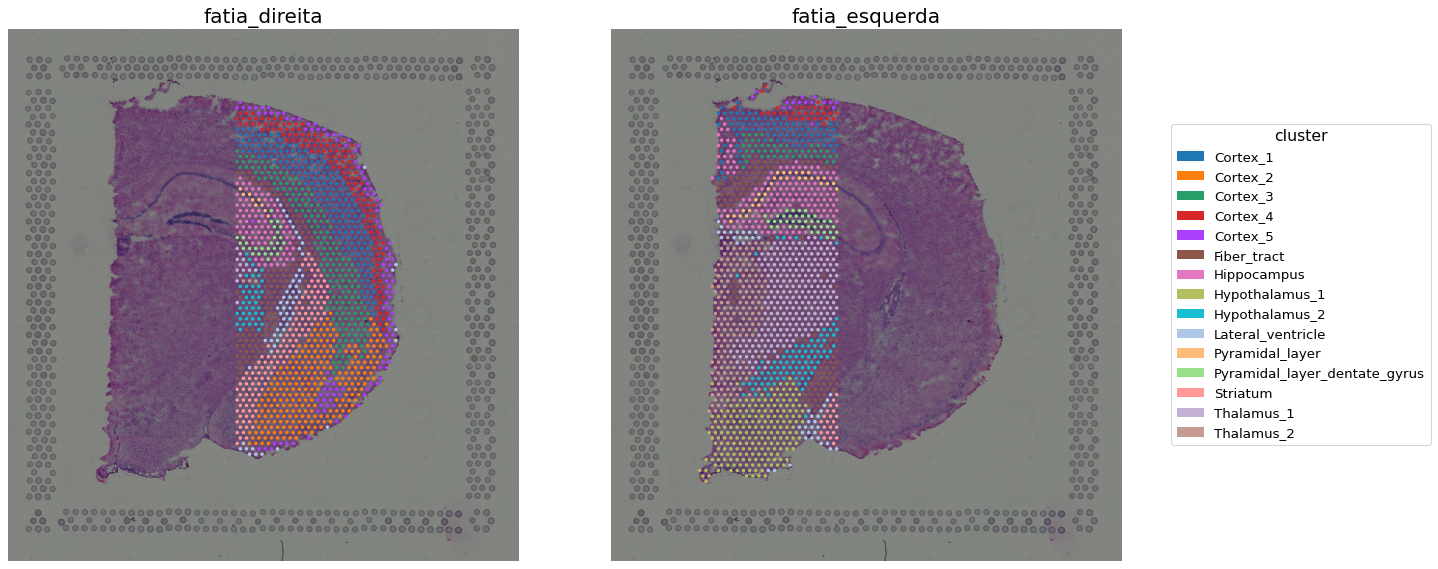

In [9]:
x = adata.obsm["spatial"][:, 0]
adata.obs["fatia"] = np.where(x < np.median(x), "fatia_esquerda", "fatia_direita")
adata.obs["fatia"] = adata.obs["fatia"].astype("category")

# cada amostra precisa da própria entrada em uns["spatial"] (aqui reusamos a mesma imagem)
for k in adata.obs["fatia"].cat.categories:
    adata.uns["spatial"][k] = adata.uns["spatial"][CHAVE]

st.pl.spatial_plot(
    adata,
    group="cluster",
    sample_key="fatia",
    ncols=2,
    spot_size=10,
    figsize=(15, 7),
    dpi=80,
)

## 2. `bar` — composição de clusters por grupo

Barras empilhadas de `clusters_col` dentro de cada `group_by`. Com `use_percentage=True`
(padrão) cada barra soma 100%, o que compara composição entre grupos de tamanhos
diferentes; com `False` mostra contagem absoluta.

Vamos agrupar as regiões anotadas por macro-região.

In [10]:
adata.obs["regiao"] = adata.obs["cluster"].astype(str).str.split("_").str[0]
adata.obs["regiao"] = adata.obs["regiao"].astype("category")

adata.obs["regiao"].value_counts()

regiao
Cortex          1078
Thalamus         453
Hypothalamus     341
Fiber            226
Hippocampus      222
Striatum         153
Pyramidal        110
Lateral          105
Name: count, dtype: int64

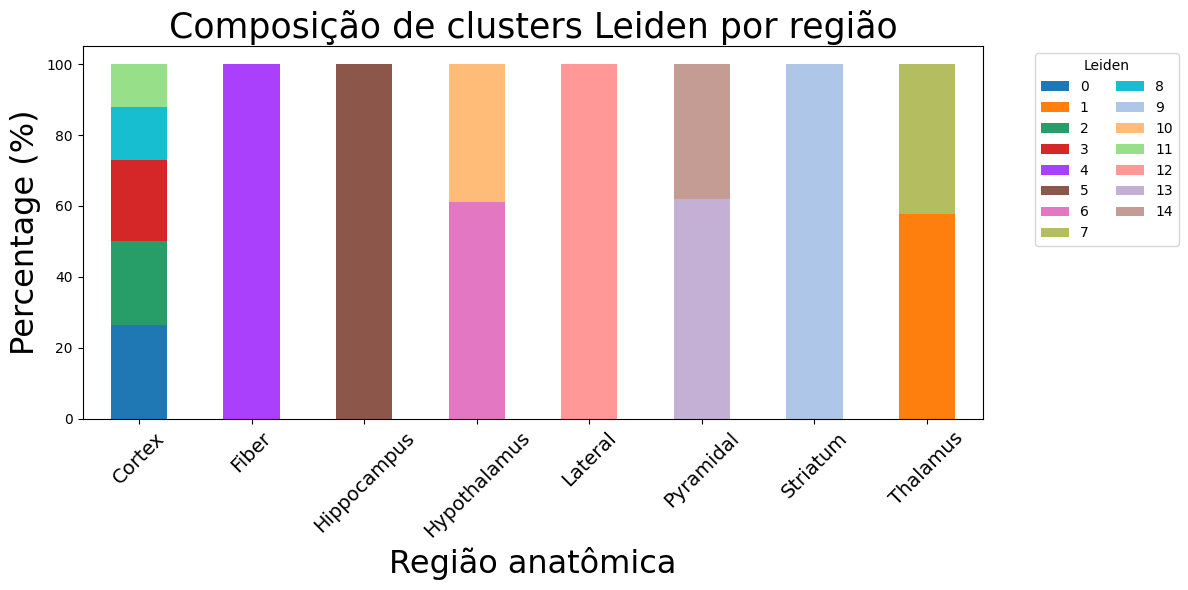

In [11]:
st.pl.bar(
    adata,
    clusters_col="leiden",
    group_by="regiao",
    title="Composição de clusters Leiden por região",
    xlabel="Região anatômica",
    legend="Leiden",
    angle=45,
)

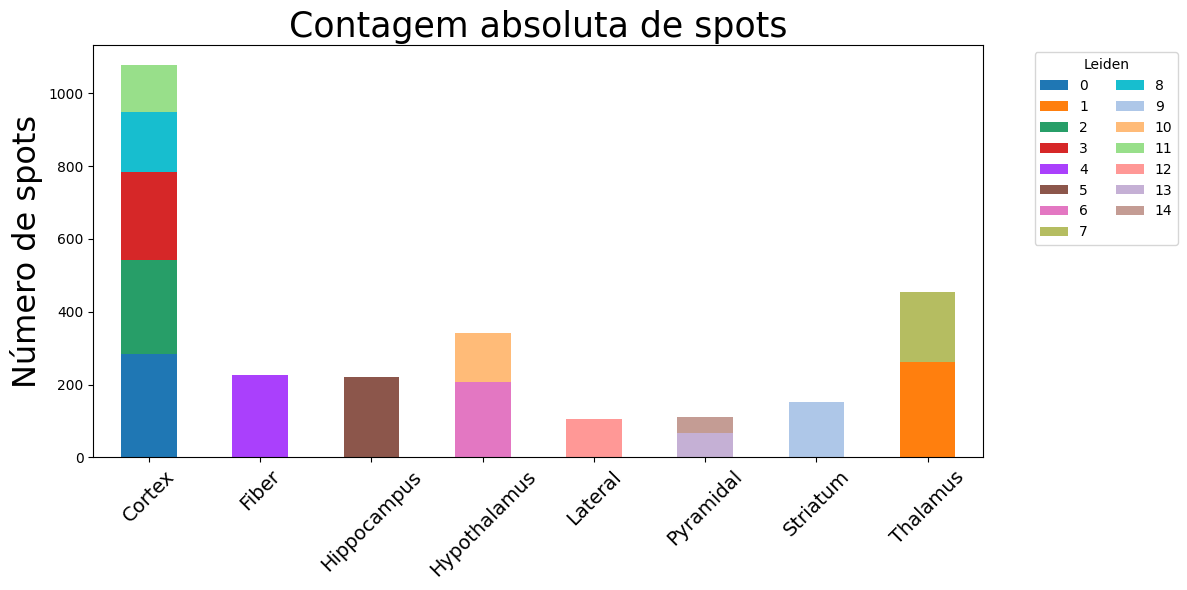

In [12]:
# Contagem absoluta em vez de porcentagem
st.pl.bar(
    adata,
    clusters_col="leiden",
    group_by="regiao",
    use_percentage=False,
    ylabel="Número de spots",
    title="Contagem absoluta de spots",
    legend="Leiden",
    angle=45,
)

### Ordem e cores customizadas

`group_order` fixa a ordem das barras no eixo x. `custom_colors` aceita um dict
`{categoria: cor}` — recomendado quando os rótulos não são numéricos (nomes de amostra,
IDs de paciente), porque aí a associação por posição não é confiável.

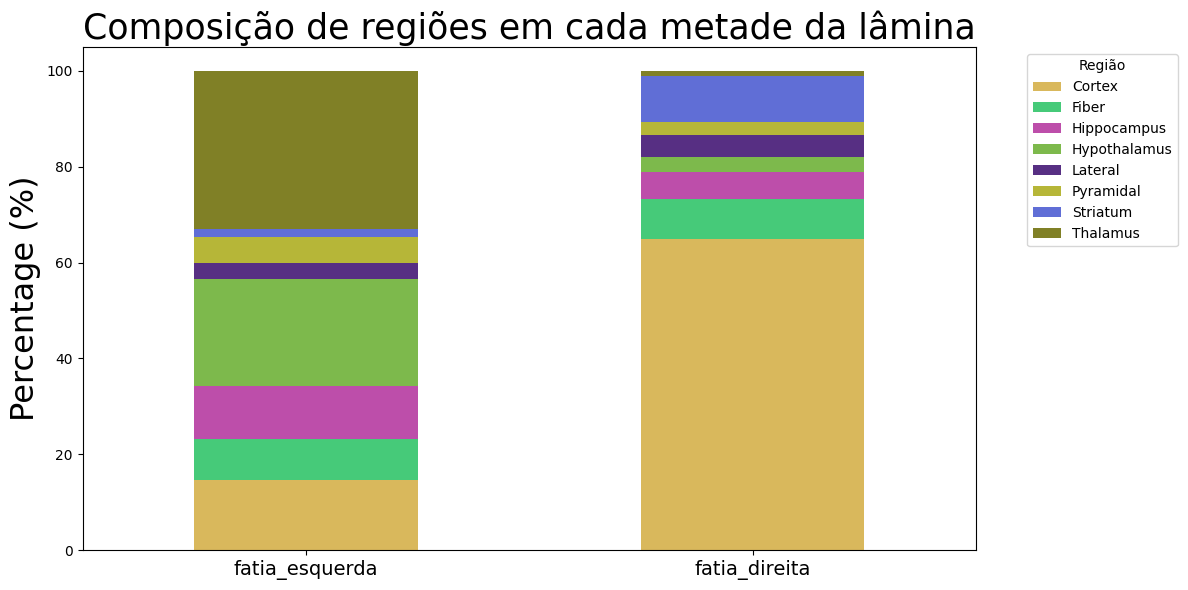

In [13]:
ordem = ["Cortex", "Thalamus", "Hippocampus", "Striatum", "Hypothalamus"]

cores = dict(zip(adata.obs["regiao"].cat.categories, st.con.BATCH_COLORS))

st.pl.bar(
    adata,
    clusters_col="regiao",
    group_by="fatia",
    group_order=["fatia_esquerda", "fatia_direita"],
    custom_colors=cores,
    title="Composição de regiões em cada metade da lâmina",
    legend="Região",
    angle=0,
)

## 3. `clusters_quality_violin_boxplot`

Violino + boxplot de uma métrica por cluster — o jeito rápido de ver se algum cluster é
puro artefato técnico (poucos reads, poucos genes, muito conteúdo mitocondrial).

⚠️ Dois requisitos: `clusters_col` precisa ter rótulos **numéricos** (`"0"`, `"1"`, …,
como o Leiden produz) e `adata.uns[f"{clusters_col}_colors"]` precisa existir, porque as
cores dos violinos vêm de lá.

In [14]:
print("rótulos do leiden:", list(adata.obs["leiden"].cat.categories))
print("cores disponíveis :", len(adata.uns["leiden_colors"]))

rótulos do leiden: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14']
cores disponíveis : 15


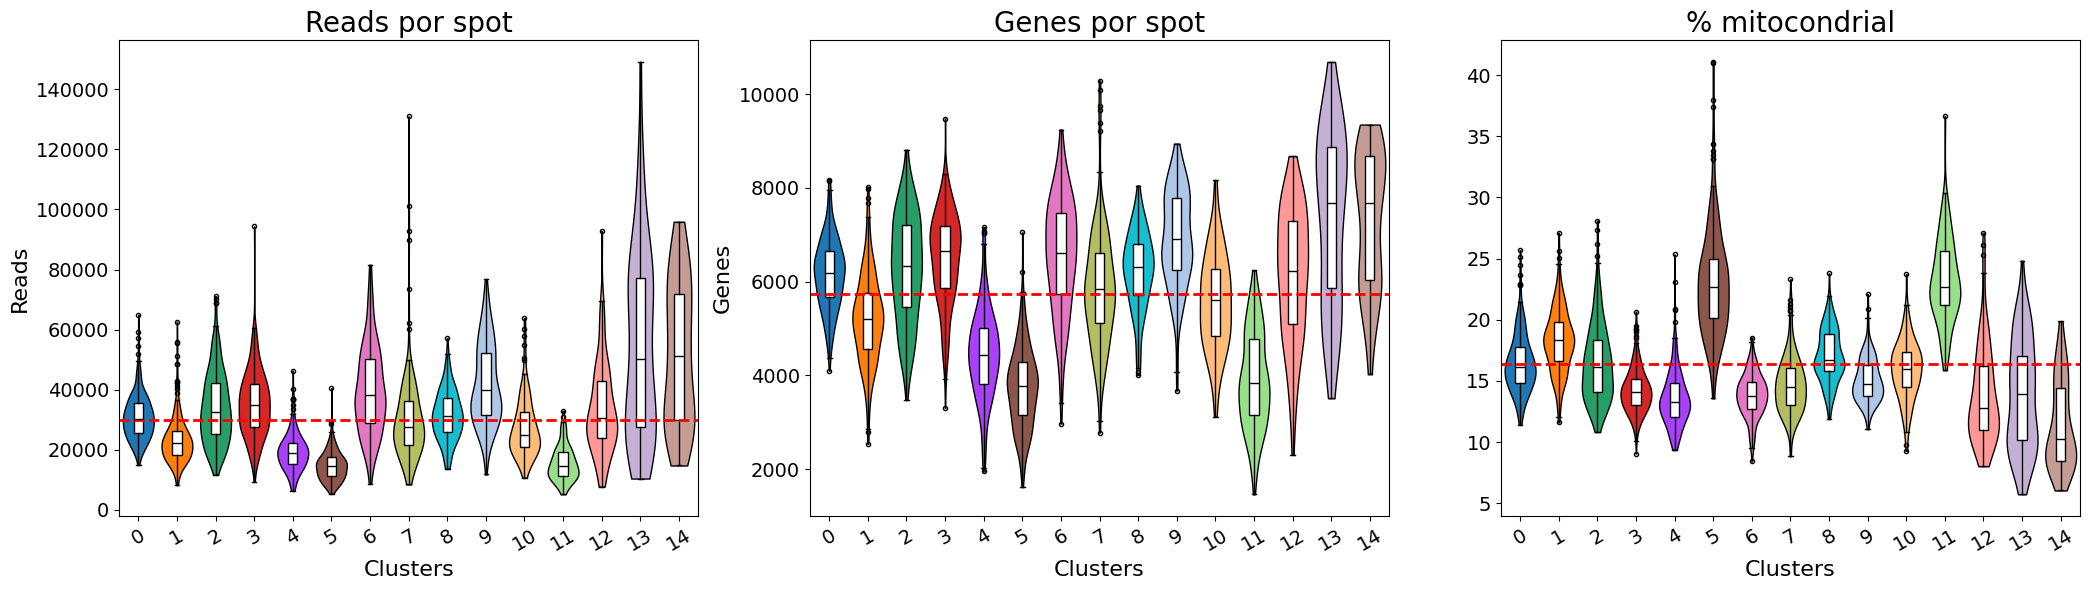

In [15]:
st.pl.clusters_quality_violin_boxplot(
    adata,
    clusters_col="leiden",
    value_col=["total_counts", "n_genes_by_counts", "pct_counts_mt"],
    titles=["Reads por spot", "Genes por spot", "% mitocondrial"],
    figsize=(7, 6),
)

## 4. Paletas prontas — `st.con`

O módulo `constants` traz duas listas de cores em hexadecimal, pensadas para serem
distinguíveis mesmo com muitas categorias:

- **`COLORS_23_HEX`** — 23 cores, para clusters
- **`BATCH_COLORS`** — 29 cores, para amostras/batches

Atribua a `adata.uns[f"{coluna}_colors"]` e todas as funções do `st.pl` (e do scanpy)
passam a usá-las.

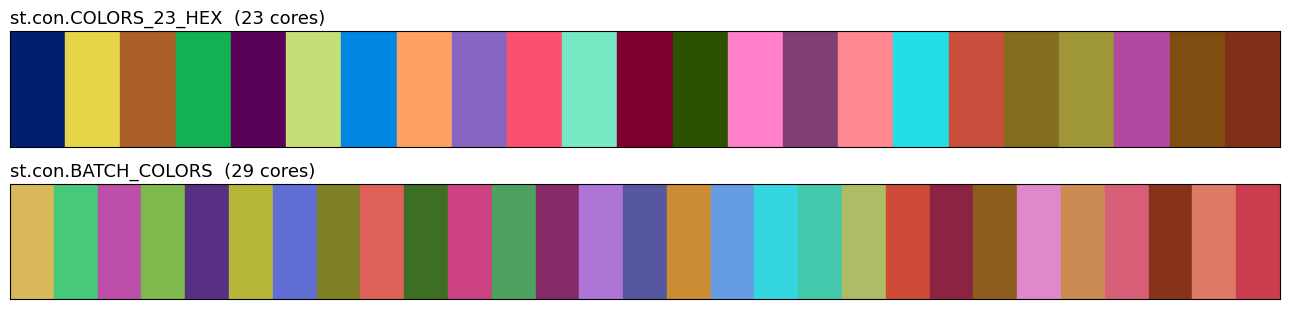

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(13, 3.2))

for ax, (nome, paleta) in zip(axes, [("COLORS_23_HEX", st.con.COLORS_23_HEX),
                                     ("BATCH_COLORS", st.con.BATCH_COLORS)]):
    for i, cor in enumerate(paleta):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=cor))
    ax.set_xlim(0, len(paleta))
    ax.set_ylim(0, 1)
    ax.set_title(f"st.con.{nome}  ({len(paleta)} cores)", fontsize=13, loc="left")
    ax.set_yticks([])
    ax.set_xticks([])

plt.tight_layout()
plt.show()

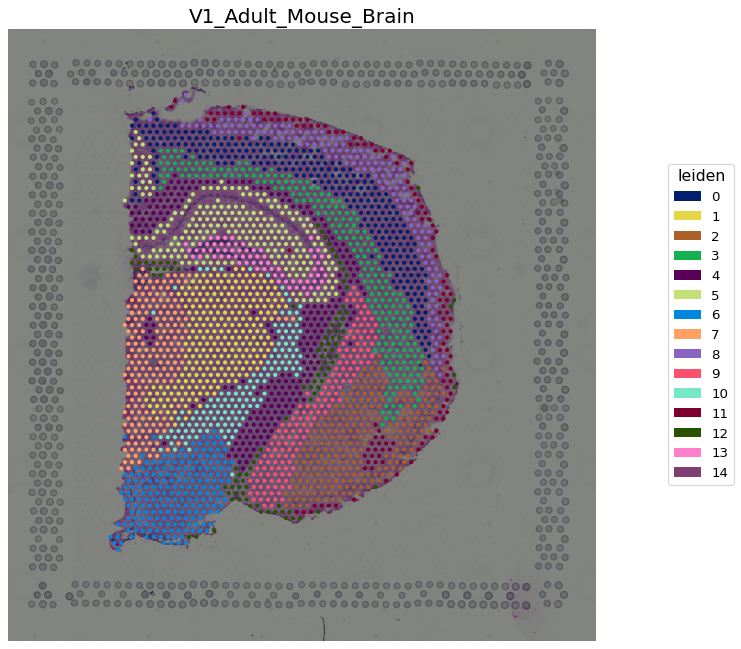

In [17]:
# Aplicando a paleta do pacote aos clusters do Leiden
adata.uns["leiden_colors"] = st.con.COLORS_23_HEX[: adata.obs["leiden"].nunique()]

st.pl.spatial_plot(
    adata,
    group="leiden",
    sample_key="sample",
    spot_size=14,
    figsize=(9, 8),
    dpi=80,
)

## Próximos passos

- [Pre-processing.ipynb](./Pre-processing.ipynb) — `outlier_quality` e
  `preprocessing_quality_metrics` para avaliar a filtragem
- [clustering_correlation_analysis.ipynb](./clustering_correlation_analysis.ipynb) —
  `z_score_matrixplot` e `boxplot_cluster_correlations` para colocalização